# Experimento 15 (protocol analysis/Ju05)

Investigar a estrutura biomecânica da marcha em condição Ju05 utilizando K-Means sem redução dimensional.

A condição Ju05 representa a caminhada sem estímulo auditivo imediatamente após a condição Ju04.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

ju_file = BASE_PATH / 'ju_baseline_features.csv'

ju_df = pd.read_csv(ju_file)

ju_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ju,JuCo06_01,491.034501,458.574755,408.370356,387.052169,0.831653,0.844033,32.459747,32.459747,1003.64,1011.23
1,Ju,JuPt28_04,463.802448,441.058882,402.657635,390.279068,0.868166,0.884868,22.743566,22.743566,1014.09,1015.41
2,Ju,JuPt28_05,461.044277,439.617162,404.446082,392.266889,0.877239,0.892292,21.427115,21.427115,1018.93,1013.32
3,Ju,JuCo19_01,397.458941,384.621782,351.571417,335.652774,0.884548,0.872683,12.837160,12.837160,944.13,906.73
4,Ju,JuPt03_05,447.612376,449.400087,376.883198,395.509597,0.841986,0.880083,-1.787712,1.787712,1045.11,1016.07


In [4]:
ju_df.shape

(129, 12)

In [5]:
ju_df.info()
ju_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          129 non-null    object 
 1   patient_id       129 non-null    object 
 2   mean_total_L     129 non-null    float64
 3   mean_total_R     129 non-null    float64
 4   std_total_L      129 non-null    float64
 5   std_total_R      129 non-null    float64
 6   cv_total_L       129 non-null    float64
 7   cv_total_R       129 non-null    float64
 8   assimetria_mean  129 non-null    float64
 9   assimetria_abs   129 non-null    float64
 10  peak_force_L     129 non-null    float64
 11  peak_force_R     129 non-null    float64
dtypes: float64(10), object(2)
memory usage: 12.2+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,455.051828,457.171072,393.188616,395.117905,0.865350,0.865192,-2.119244,27.710268,1081.392093,1067.957597
std,71.029879,67.360979,59.454903,57.136178,0.030755,0.027199,37.795212,25.673848,167.330017,157.825427
min,297.722340,280.285646,253.381604,251.828916,0.811314,0.789306,-104.968020,0.904334,679.360000,662.200000
25%,409.533942,419.375957,356.771428,368.300552,0.840375,0.849707,-17.495787,9.383295,993.410000,970.420000
50%,461.467481,458.574755,392.219574,394.652427,0.864917,0.867851,-1.787712,19.450620,1054.020000,1024.100000
75%,493.580845,502.505420,436.113674,438.293948,0.886674,0.883101,20.686953,38.433776,1208.680000,1195.370000
max,687.630032,702.366501,612.168131,634.996815,0.938781,0.929556,86.617580,104.968020,1816.540000,1866.590000


### Filtrando somente a condição Ju05

In [6]:
ju05_df = ju_df[
    ju_df['patient_id'].str.endswith('_05')
]

ju05_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
2,Ju,JuPt28_05,461.044277,439.617162,404.446082,392.266889,0.877239,0.892292,21.427115,21.427115,1018.93,1013.32
4,Ju,JuPt03_05,447.612376,449.400087,376.883198,395.509597,0.841986,0.880083,-1.787712,1.787712,1045.11,1016.07
7,Ju,JuPt01_05,565.852313,498.108754,478.993841,448.203770,0.846500,0.899811,67.743559,67.743559,1328.58,1165.01
10,Ju,JuPt15_05,527.461635,506.774682,456.210281,439.907924,0.864917,0.868054,20.686953,20.686953,1205.93,1205.38
11,Ju,JuPt20_05,493.580845,500.386464,436.191440,434.260883,0.883728,0.867851,-6.805619,6.805619,1209.56,1213.85


Verificando o subconjunto

In [7]:
ju05_df.shape

(13, 12)

In [8]:
ju05_df['patient_id'].head(5)

,patient_id
2,JuPt28_05
4,JuPt03_05
7,JuPt01_05
10,JuPt15_05
11,JuPt20_05


### Estatísticas descritivas sobre o subconjunto

In [9]:
ju05_df.describe()

,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,470.673698,473.174915,406.069955,409.194966,0.864452,0.865890,-2.501217,29.256601,1122.423077,1107.124615
std,67.271107,65.565380,54.593391,53.949686,0.031474,0.027169,44.161542,32.089584,140.312900,126.662713
min,336.197061,340.178984,300.772494,296.753609,0.813056,0.803177,-104.968020,1.787712,903.320000,881.430000
25%,447.612376,449.400087,376.883198,392.266889,0.841986,0.866264,-6.805619,6.805619,1045.110000,1013.320000
50%,463.190591,489.129581,403.797356,433.093218,0.864917,0.868054,-1.787712,20.686953,1059.080000,1131.130000
75%,527.461635,506.774682,455.244370,448.203770,0.885199,0.880083,21.427115,28.986635,1205.930000,1213.850000
max,565.852313,567.686641,480.995526,480.278456,0.927600,0.899811,67.743559,104.968020,1404.260000,1262.910000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [10]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = ju05_df[feature_cols]

# 5. Normalização dos dados

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [12]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

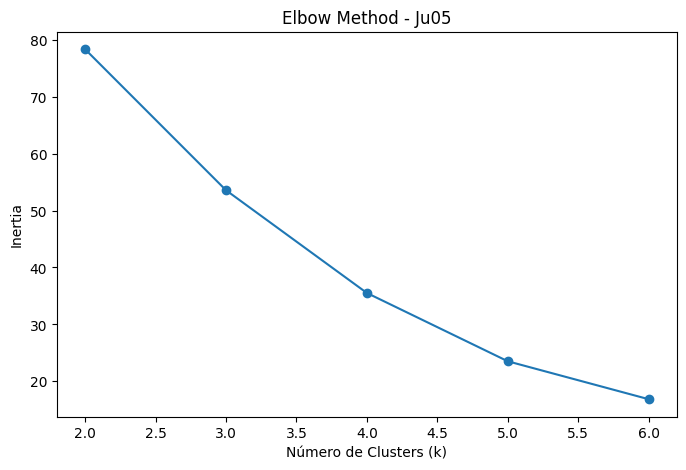

In [27]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method - Ju05')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [14]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.3070
k=3 | Silhouette Score: 0.3362
k=4 | Silhouette Score: 0.3522
k=5 | Silhouette Score: 0.3494
k=6 | Silhouette Score: 0.3073


Vizualização com o Silhouette Score

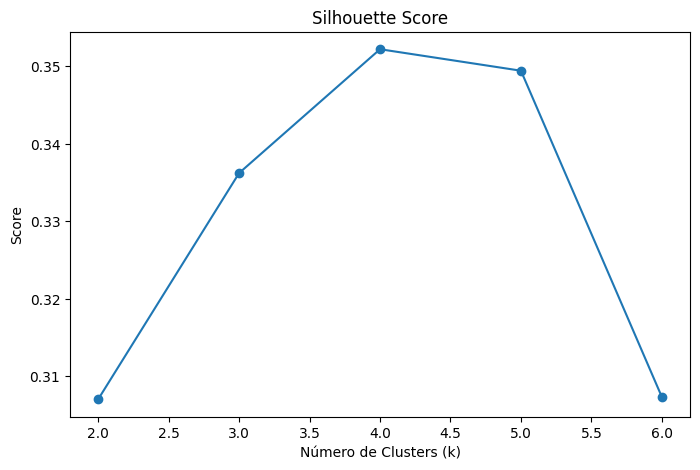

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [17]:
ju05_df['cluster'] = clusters

ju05_df.head()

/tmp/ipykernel_52049/400374052.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ju05_df['cluster'] = clusters


,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
2,Ju,JuPt28_05,461.044277,439.617162,404.446082,392.266889,0.877239,0.892292,21.427115,21.427115,1018.93,1013.32,2
4,Ju,JuPt03_05,447.612376,449.400087,376.883198,395.509597,0.841986,0.880083,-1.787712,1.787712,1045.11,1016.07,2
7,Ju,JuPt01_05,565.852313,498.108754,478.993841,448.203770,0.846500,0.899811,67.743559,67.743559,1328.58,1165.01,1
10,Ju,JuPt15_05,527.461635,506.774682,456.210281,439.907924,0.864917,0.868054,20.686953,20.686953,1205.93,1205.38,1
11,Ju,JuPt20_05,493.580845,500.386464,436.191440,434.260883,0.883728,0.867851,-6.805619,6.805619,1209.56,1213.85,1


# 9. Métricas Internas

In [18]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.3522
Davies-Bouldin Index: 0.8492
Calinski-Harabasz Score: 7.9795


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

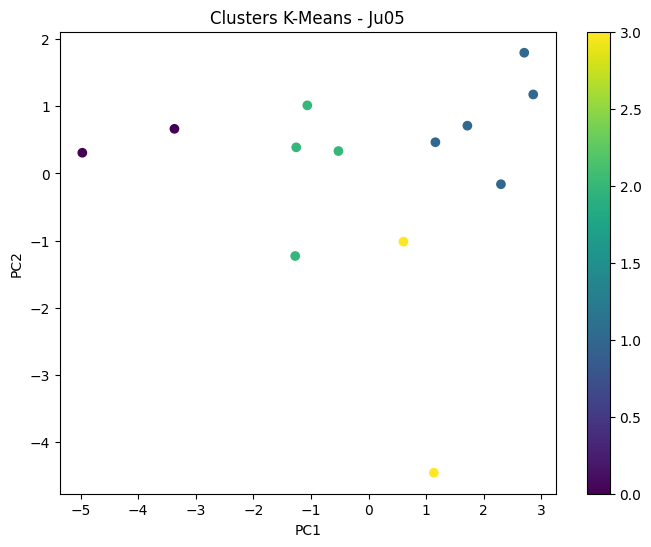

In [28]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means - Ju05')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [21]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

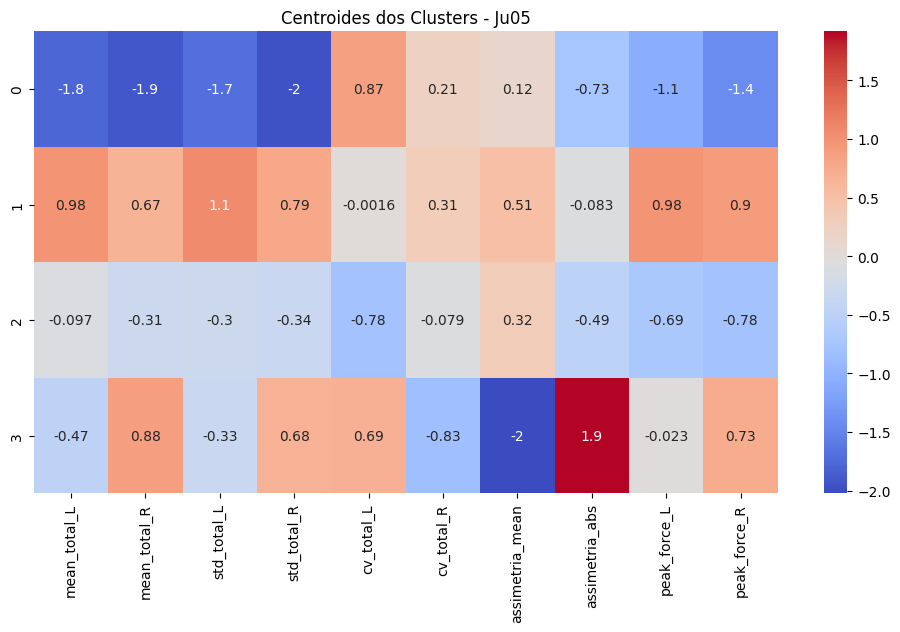

In [29]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters - Ju05')

plt.show()

# 12. Distribuição dos Clusters

In [23]:
ju05_df['cluster'].value_counts()

,count
cluster,
1,5
2,4
0,2
3,2


# 13. Composição por Grupo Clínico

Parkinson vs Controle

In [24]:
ju05_df['grupo'] = np.where(
    ju05_df['patient_id'].str.contains('Pt'),
    'Parkinson',
    'Controle'
)

/tmp/ipykernel_52049/2130682973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ju05_df['grupo'] = np.where(


In [25]:
pd.crosstab(
    ju05_df['cluster'],
    ju05_df['grupo']
)

grupo,Parkinson
cluster,
0,2
1,5
2,4
3,2


# 14. Média das features por cluster

In [26]:
ju05_df.groupby(
    'cluster'
)[feature_cols].mean()

,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
cluster,,,,,,,,,,
0,355.008184,352.336418,316.114179,307.028547,0.890653,0.871439,2.671766,6.653689,979.715,932.9100
1,534.230850,515.265372,461.527092,450.212032,0.864402,0.873963,18.965478,26.702840,1255.144,1217.1500
2,464.387552,453.364493,390.431678,391.342865,0.840912,0.863817,11.023059,14.183816,1029.435,1012.1375
3,440.018624,528.408111,388.659443,444.522926,0.885454,0.844307,-88.389487,88.389487,1119.305,1196.2500
